# MVP — Machine Learning & Analytics

**Nome:** _Leonardo Valério Rodrigues Pires_  
**Matrícula:** _4052025000144_  
**Data:** _04/07/2026_  
**Dataset:** _El Niño Data Set — TAO Project (UCI Machine Learning Repository) — https://archive.ics.uci.edu/dataset/122/el+nino_  
**Tipo de problema:** _Regressão_  

---


## Checklist do MVP

| Item | Status | Onde |
|---|---|---|
| Problema definido com contexto, objetivo e tipo de tarefa | ✅ | Seções 1.1–1.3 |
| Dataset descrito, com fonte, atributos e restrições | ✅ | Seções 3.1 e 3.4 |
| Dataset carregado por URL pública ou fonte diretamente acessível | ✅ | Seção 3.2 (URL raw do GitHub) |
| Análise exploratória objetiva, conectada à modelagem | ✅ | Seção 4 (orientada pelas hipóteses H1–H3) |
| Divisão adequada em treino/teste e, se aplicável, validação | ✅ | Seções 5 e 5.1 |
| Prevenção de vazamento de dados | ✅ | Seções 5.1 e 6 (pipeline ajustado só no treino; teste usado uma única vez) |
| Tratamentos de dados justificados | ✅ | Seções 6 e 6.1 |
| Pipeline ou sequência reprodutível de pré-processamento | ✅ | Seção 6 (`Pipeline` do scikit-learn) |
| Modelo baseline definido | ✅ | Seção 7 (DummyRegressor, mediana) |
| Pelo menos dois modelos/abordagens comparados | ✅ | Seções 7–8 (três candidatos: Linear, KNN, HistGradientBoosting) |
| Ajuste de hiperparâmetros em pelo menos um modelo | ✅ | Seção 9 (RandomizedSearchCV, K-Fold 5) |
| Avaliação com métricas coerentes com o problema | ✅ | Seções 1.4 e 10 (RMSE, MAE, R²) |
| Discussão de overfitting/underfitting, limitações e melhorias | ✅ | Seções 8.1, 10.1 e 13 |
| Código limpo, organizado e executável do início ao fim | ✅ | Todo o notebook (seed 42, funções auxiliares, sem dependências extras) |
| Conclusão conectada ao objetivo inicial | ✅ | Seção 13 (hipóteses e critérios de sucesso retomados) |

Itens do template não aplicáveis a este problema: divisão temporal (o problema
não é forecasting — justificativa na Seção 5.1), avaliação de clusterização
(problema supervisionado) e deep learning/fine-tuning (opcional; um modelo
clássico atendeu aos critérios de sucesso com folga).

# 1. Definição do problema

## 1.1 Descrição do problema

O fenômeno El Niño/La Niña (ciclo ENSO — El Niño-Southern Oscillation) é uma
oscilação da temperatura da superfície do mar no Pacífico equatorial que afeta
o clima em escala global, influenciando regimes de chuva, secas, agricultura e
gestão de desastres naturais — inclusive no Brasil, onde episódios de El Niño
estão associados a secas no Norte/Nordeste e chuvas intensas no Sul.

O episódio de 1982-1983, um dos mais fortes do século XX, não foi previsto nem
detectado até estar próximo do pico, causando enchentes destrutivas no Peru e
nos EUA e secas e incêndios no Pacífico Ocidental. Esse evento motivou a criação
do TAO Array (Tropical Atmosphere Ocean), uma rede de boias oceanográficas
posicionadas ao longo do Pacífico equatorial que mede continuamente variáveis
atmosféricas e oceânicas.

A variável central de monitoramento do ENSO é a **temperatura da superfície do
mar (SST — Sea Surface Temperature)**. Este trabalho investiga se é possível
estimar a SST a partir das demais medições disponíveis nas boias (ventos zonais
e meridionais, umidade relativa, temperatura do ar) e do contexto espacial e
temporal da medição (latitude, longitude, época do ano).

Uma solução desse tipo interessa a centros de pesquisa climática e meteorologia:
sensores de SST podem falhar ou apresentar lacunas (o próprio dataset contém
valores ausentes), e um modelo capaz de estimar a SST a partir das demais
variáveis apoia o preenchimento dessas lacunas e o controle de qualidade das
medições da rede de boias.

## 1.2 Objetivo do MVP

O objetivo deste MVP é construir e avaliar modelos de Machine Learning para
**prever a temperatura da superfície do mar (SST)** no Pacífico equatorial a
partir das medições meteorológicas das boias do TAO Array (ventos zonais e
meridionais, umidade relativa e temperatura do ar) e do contexto espacial e
temporal de cada observação (latitude, longitude e mês), comparando uma
abordagem baseline com modelos candidatos e discutindo suas limitações.


## 1.3 Tipo de problema

**Tipo escolhido:** Regressão

**Justificativa:** A variável-alvo (`ss_temp`, temperatura da superfície do mar
em °C) é numérica e contínua, o que caracteriza um problema de regressão
supervisionada. Não se trata de classificação, pois não há categorias a prever;
e, embora o dataset possua dimensão temporal (medições diárias de 1980 a 1998),
o problema **não** foi enquadrado como previsão de séries temporais: o objetivo
não é prever valores futuros da SST, e sim estimá-la a partir de variáveis
medidas no mesmo instante — cenário típico de imputação de lacunas e controle
de qualidade de sensores, conforme descrito na Seção 1.1. Essa escolha de
enquadramento tem consequências para a divisão dos dados, discutidas na Seção 5.


## 1.4 Premissas, hipóteses e critérios de sucesso

**Premissas:**
- As medições das boias do TAO Array são suficientemente confiáveis para
  treinar e avaliar modelos, ainda que contenham valores ausentes.
- As variáveis explicativas estariam disponíveis no momento real da estimativa
  (todas são medidas pelas próprias boias no mesmo instante da SST), o que
  torna o cenário de uso realista.

**Hipóteses iniciais:**
1. **H1:** A temperatura do ar (`air_temp`) é o preditor mais forte da SST,
   dado o acoplamento físico entre oceano e atmosfera na camada superficial.
2. **H2:** A longitude é relevante para a previsão, pois o aquecimento do
   Pacífico equatorial é assimétrico — a "piscina quente" fica no Pacífico
   Ocidental e a "língua fria" no Oriental —, de modo que a posição da boia
   carrega informação sobre a SST esperada.
3. **H3:** Modelos não lineares (baseados em árvores ou vizinhança) superam
   um modelo linear simples, pois a relação entre ventos, umidade e SST
   envolve interações e não linearidades.

**Critérios de sucesso:**
- **Métrica principal:** RMSE (erro em °C, na mesma unidade da variável-alvo,
  penalizando mais os erros grandes — relevantes em eventos extremos do ENSO).
- **Métricas de apoio:** MAE e R².
- **Resultado mínimo esperado:** o melhor modelo deve reduzir o RMSE em pelo
  menos **50% em relação ao baseline** (DummyRegressor que prevê a mediana) e
  atingir **R² ≥ 0,80** no conjunto de teste.
- **Restrição prática:** o notebook deve executar do início ao fim no Google
  Colab gratuito (CPU) em tempo razoável, sem dependências além do ecossistema
  padrão (pandas, numpy, scikit-learn, matplotlib).


# 2. Ambiente, bibliotecas e reprodutibilidade

Este MVP utiliza apenas bibliotecas do ecossistema padrão de Data Science em
Python, todas pré-instaladas no Google Colab: **pandas** e **numpy** para
manipulação de dados, **matplotlib** para visualização e **scikit-learn** para
pré-processamento, modelagem e avaliação. Não há dependências externas a
instalar, o que reduz o risco de falhas de execução.

A seed é fixada em 42 e propagada para todas as operações estocásticas
(divisão treino/teste, modelos e busca de hiperparâmetros), garantindo
reprodutibilidade dos resultados.

Todo o treinamento é feito em **CPU** — os modelos escolhidos (lineares,
vizinhança e ensembles de árvores via scikit-learn) não se beneficiam de GPU.
As versões das bibliotecas são impressas abaixo para rastreabilidade.

In [1]:
# === Setup básico e reprodutibilidade ===
import sys
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from scipy.stats import randint, uniform

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("Seed:", SEED)

Python: 3.12.13
pandas: 2.2.2
numpy: 2.0.2
scikit-learn: 1.6.1
Seed: 42


## 2.1 Dependências adicionais

Não foram necessárias dependências além das bibliotecas pré-instaladas no
Google Colab (pandas, numpy, matplotlib, scikit-learn e scipy). Essa decisão
é intencional: manter o projeto restrito ao ecossistema padrão elimina o risco
de falha de instalação no momento da correção e atende à restrição prática
definida na Seção 1.4.


## 2.2 Funções auxiliares

Para evitar repetição de código, as métricas de regressão (MAE, RMSE e R²)
são calculadas por uma única função, usada na avaliação do baseline, dos
modelos candidatos e do modelo final. Uma segunda função exibe os resultados
acumulados em formato de tabela, facilitando a comparação entre modelos.


In [2]:
def evaluate_regression(y_true, y_pred):
    """Calcula métricas básicas de regressão: MAE, RMSE e R²."""
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred)
    }


def show_results_table(results_dict):
    """Exibe os resultados acumulados como DataFrame para comparação."""
    return pd.DataFrame(results_dict).T

# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

**Dataset:** El Niño Data Set — TAO Project
**Fonte:** UCI Machine Learning Repository — https://archive.ics.uci.edu/dataset/122/el+nino
**DOI:** 10.24432/C5WG62

Os dados foram coletados pelas boias oceanográficas do **TAO Array (Tropical
Atmosphere Ocean)**, rede mantida pelo Pacific Marine Environmental Laboratory
(NOAA) no Pacífico equatorial, com medições diárias entre 1980 e 1998. Cada
registro corresponde a uma leitura de uma boia em uma data, contendo posição
(latitude e longitude), ventos zonais e meridionais, umidade relativa,
temperatura do ar e temperatura da superfície do mar (SST).

**Por que este dataset foi escolhido:**
- conecta-se a um problema real e relevante (monitoramento do ciclo ENSO,
  descrito na Seção 1.1), permitindo hipóteses com fundamento físico;
- tem volume expressivo (~178 mil registros), suficiente para treinar e
  comparar modelos com divisão treino/teste confiável;
- contém **valores ausentes reais** (codificados como "." no arquivo original),
  exigindo decisões genuínas de preparação de dados, e não tratamento
  artificial de uma base já limpa;
- não foi utilizado nas aulas da sprint, conforme exigido nos requisitos.

**Restrições e condições consideradas:** o arquivo original (`tao-all2.dat`)
não possui cabeçalho e usa espaço como separador; os nomes das colunas foram
obtidos do arquivo `tao-all2.col` da própria fonte. O dataset possui dimensão
temporal, o que impôs a discussão de enquadramento feita na Seção 1.3 e
retomada na divisão dos dados (Seção 5).

**Ética, privacidade e licença:** trata-se de dados ambientais de sensores,
sem qualquer informação pessoal — não há questões de privacidade ou
confidencialidade. O dataset é distribuído sob licença **Creative Commons
Attribution 4.0 (CC BY 4.0)**, que permite uso e redistribuição com atribuição
da fonte. Por isso, uma cópia em CSV foi hospedada em repositório público do
GitHub para carga direta pelo notebook (Seção 3.2), mantendo a citação à
fonte original.

**Citação:** El Nino [Dataset]. (1999). UCI Machine Learning Repository.
https://doi.org/10.24432/C5WG62

## 3.2 Carga dos dados

O dataset é carregado diretamente de um repositório público do GitHub, por meio
da URL raw do arquivo CSV. Essa abordagem garante que o notebook execute do
início ao fim sem upload manual, autenticação, token ou configuração local.

O arquivo `elnino.csv` hospedado no repositório é uma conversão direta do
arquivo original `tao-all2.dat.gz` do UCI: os nomes das colunas foram aplicados
conforme o arquivo `tao-all2.col` da fonte, e os valores ausentes (codificados
como ".") foram convertidos para valores nulos. Nenhuma linha foi removida ou
alterada nessa conversão — todo o tratamento de dados é feito neste notebook,
de forma transparente e reproduzível.

In [3]:
url = "https://raw.githubusercontent.com/computeibr/MVP_ML_Analytics_20261_v1/refs/heads/main/elnino.csv"
df = pd.read_csv(url)
print("Formato do dataset:", df.shape)
df.head()

Formato do dataset: (178080, 12)


,obs,year,month,day,date,latitude,longitude,zon_winds,mer_winds,humidity,air_temp,ss_temp
0,1,80,3,7,800307,-0.02,-109.46,-6.8,0.7,NaN,26.14,26.24
1,2,80,3,8,800308,-0.02,-109.46,-4.9,1.1,NaN,25.66,25.97
2,3,80,3,9,800309,-0.02,-109.46,-4.5,2.2,NaN,25.69,25.28
3,4,80,3,10,800310,-0.02,-109.46,-3.8,1.9,NaN,25.57,24.31
4,5,80,3,11,800311,-0.02,-109.46,-4.2,1.5,NaN,25.30,23.19


## 3.3 Visão geral do dataset

In [4]:
# === Visão geral do dataset ===

print("Formato do dataset:", df.shape)

print("\nTipos de dados:")
display(df.dtypes.to_frame("tipo"))

print("\nValores ausentes por coluna:")
missing = df.isna().sum().to_frame("ausentes")
missing["percentual"] = (missing["ausentes"] / len(df) * 100).round(2)
display(missing)

print("\nLinhas duplicadas:", df.duplicated().sum())

print("\nAmostra aleatória:")
display(df.sample(5, random_state=SEED))

Formato do dataset: (178080, 12)

Tipos de dados:


,tipo
obs,int64
year,int64
month,int64
day,int64
date,int64
latitude,float64
longitude,float64
zon_winds,float64
mer_winds,float64
humidity,float64



Valores ausentes por coluna:


,ausentes,percentual
obs,0,0.00
year,0,0.00
month,0,0.00
day,0,0.00
date,0,0.00
latitude,0,0.00
longitude,0,0.00
zon_winds,25163,14.13
mer_winds,25162,14.13
humidity,65761,36.93



Linhas duplicadas: 0

Amostra aleatória:


,obs,year,month,day,date,latitude,longitude,zon_winds,mer_winds,humidity,air_temp,ss_temp
147093,147094,98,2,27,980227,8.04,-110.15,-4.8,-6.6,NaN,NaN,28.39
120188,120189,86,1,11,860111,-5.01,-109.86,NaN,NaN,NaN,23.63,23.71
173783,173784,96,8,2,960802,-8.03,-95.08,NaN,NaN,81.1,22.22,22.93
17024,17025,93,5,10,930510,0.10,155.39,NaN,NaN,84.8,27.26,29.14
121252,121253,89,10,16,891016,-4.97,-109.99,-6.4,0.9,NaN,23.02,22.91


### Interpretação da visão geral

O dataset possui **178.080 registros e 12 colunas**, todas numéricas. As
colunas que continham "." no arquivo original foram corretamente carregadas
como `float` com valores nulos, confirmando que a conversão descrita na
Seção 3.2 preservou a codificação de ausentes.

**Valores ausentes:** concentram-se exclusivamente nas medições dos sensores:
`humidity` (36,93%), `zon_winds` e `mer_winds` (14,13% cada), `air_temp`
(10,24%) e `ss_temp` (9,55%). As colunas de posição e tempo não têm ausentes —
padrão coerente com a natureza dos dados: posição e data sempre existem, mas
sensores falham ou não estavam instalados (as boias mais antigas, de 1980,
não mediam umidade, como se observa nas primeiras linhas da base). Dois casos
merecem destaque:

- **`ss_temp` (9,55% ausente):** por ser a **variável-alvo**, essas linhas não
  podem ser usadas nem para treinar nem para avaliar — imputar o valor que se
  deseja prever contaminaria o experimento. Serão removidas na Seção 5.
- **`humidity` (36,93% ausente):** percentual alto demais para imputação
  trivial. A decisão entre imputar com indicador de ausência ou descartar a
  variável será tomada na Seção 6, após a EDA avaliar sua relação com o alvo.

**Duplicatas:** 0 linhas duplicadas. Vale a ressalva de que a coluna `obs`
(identificador sequencial) torna cada linha única por construção; após sua
remoção, eventuais combinações repetidas de medições seriam leituras legítimas
de boias/dias distintos, não erro de coleta.

**Colunas que não devem entrar no modelo:**
- `obs`: identificador sequencial — não carrega informação;
- `date`: data no formato `aammdd` (ex.: `800307` = 07/03/1980), redundante
  com `year`, `month` e `day`;
- `year` (2 dígitos: 80–98) e `day`: candidatas à exclusão, com decisão final
  na EDA — `year` identifica episódios ENSO específicos e pode comprometer a
  generalização; `day` não tem relação física esperada com a SST.

**Variável-alvo:** `ss_temp` — temperatura da superfície do mar em °C,
numérica e contínua, conforme definido na Seção 1.3.


## 3.4 Dicionário de dados

| Coluna | Tipo | Descrição | Será usada no modelo? | Observações |
|---|---|---|---|---|
| `obs` | numérica (int) | Identificador sequencial da observação | não | ID sem conteúdo informativo |
| `year` | numérica (int) | Ano da medição, 2 dígitos (80–98 = 1980–1998) | não* | Decisão confirmada na EDA: identifica episódios ENSO específicos e comprometeria a generalização para anos futuros |
| `month` | numérica (int) | Mês da medição (1–12) | sim | Captura a sazonalidade, com relação física esperada com a SST |
| `day` | numérica (int) | Dia do mês (1–31) | não* | Sem relação física esperada com a SST; decisão confirmada na EDA |
| `date` | data (int `aammdd`) | Data codificada (ex.: `800307` = 07/03/1980) | não | Redundante com `year`/`month`/`day` |
| `latitude` | numérica (float) | Latitude da boia (graus; ~±10° do equador) | sim | Posição no eixo norte–sul |
| `longitude` | numérica (float) | Longitude da boia (graus; negativa = oeste) | sim | Posição no eixo leste–oeste; testa a H2 (assimetria do Pacífico) |
| `zon_winds` | numérica (float) | Vento zonal, m/s (oeste < 0, leste > 0) | sim | 14,13% ausentes — imputação na Seção 6 |
| `mer_winds` | numérica (float) | Vento meridional, m/s (sul < 0, norte > 0) | sim | 14,13% ausentes — imputação na Seção 6 |
| `humidity` | numérica (float) | Umidade relativa (%) | sim* | 36,93% ausentes — decisão sobre imputação vs. descarte na Seção 6, após a EDA |
| `air_temp` | numérica (float) | Temperatura do ar (°C) | sim | Preditor central da H1; 10,24% ausentes |
| `ss_temp` | **alvo** | Temperatura da superfície do mar (°C) | alvo | Valor contínuo a prever; linhas sem alvo (9,55%) removidas na Seção 5 |

\* Decisões marcadas com asterisco são preliminares e serão confirmadas ou
revistas na análise exploratória (Seção 4).

# 4. Análise exploratória dos dados

A análise a seguir é orientada pelas hipóteses da Seção 1.4 e pelas decisões
pendentes do dicionário de dados (Seção 3.4): distribuição do alvo, relação
das variáveis com a SST (H1 e H2), papel do tempo (`month`, `year`, `day`)
e o destino de `humidity`. Cada gráfico é acompanhado da sua interpretação
e da consequência para a modelagem.

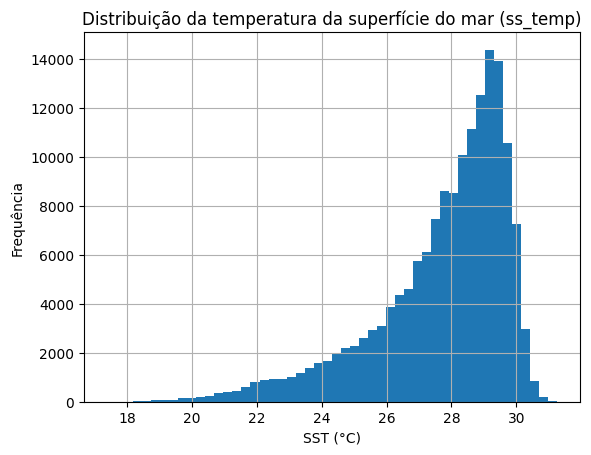

,ss_temp
count,161073.00
mean,27.72
std,2.06
min,17.35
25%,26.77
50%,28.29
75%,29.23
max,31.26


In [5]:
# === 4.A Distribuição da variável-alvo (ss_temp) ===

df["ss_temp"].hist(bins=50)
plt.title("Distribuição da temperatura da superfície do mar (ss_temp)")
plt.xlabel("SST (°C)")
plt.ylabel("Frequência")
plt.show()

display(df["ss_temp"].describe().round(2).to_frame("ss_temp"))

### Interpretação 4.A (distribuição do alvo):
A SST varia de 17,35 a 31,26 °C (média 27,72; mediana 28,29; desvio 2,06),
com distribuição **assimétrica à esquerda**: a massa concentra-se entre 26 e
30 °C e há uma cauda longa em direção às temperaturas frias. Fisicamente, a
cauda corresponde à "língua fria" do Pacífico Oriental e a episódios de
La Niña. Consequências: (i) não há valores absurdos ou impossíveis — os
extremos são oceanograficamente plausíveis, então não haverá remoção de
outliers do alvo; (ii) a assimetria sugere que os modelos podem errar mais
na cauda fria, sub-representada — ponto a verificar na análise de resíduos
(Seção 10). O `count` de 161.073 confirma a contagem prevista após excluir
os 9,55% de registros sem alvo.

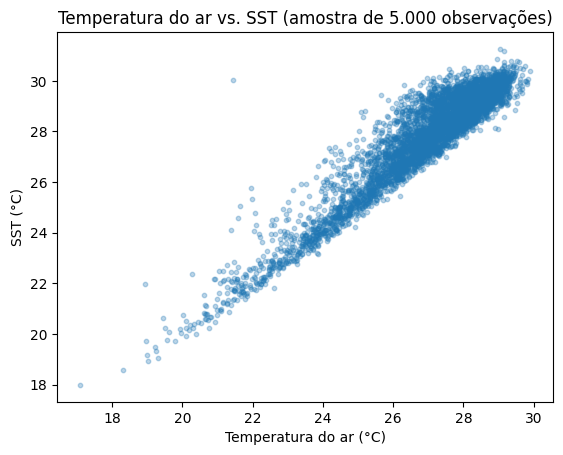

,correlação com ss_temp
air_temp,0.944
longitude,0.382
zon_winds,0.354
humidity,-0.318
mer_winds,-0.311
year,0.274
latitude,0.100
month,-0.086
day,-0.002


In [6]:
# === 4.B Relação entre as variáveis e o alvo (H1) ===

# Dispersão air_temp x ss_temp (amostra de 5.000 pontos para legibilidade)
sample = df.dropna(subset=["air_temp", "ss_temp"]).sample(5000, random_state=SEED)
plt.scatter(sample["air_temp"], sample["ss_temp"], alpha=0.3, s=10)
plt.title("Temperatura do ar vs. SST (amostra de 5.000 observações)")
plt.xlabel("Temperatura do ar (°C)")
plt.ylabel("SST (°C)")
plt.show()

# Correlação de todas as variáveis candidatas com o alvo
feature_candidates = ["latitude", "longitude", "zon_winds", "mer_winds",
                      "humidity", "air_temp", "month", "year", "day"]
corr = df[feature_candidates + ["ss_temp"]].corr()["ss_temp"].drop("ss_temp")
display(corr.sort_values(key=abs, ascending=False).round(3).to_frame("correlação com ss_temp"))

### Interpretação 4.B (H1 — correlações):

A dispersão mostra relação **linear fortíssima** entre temperatura do ar e
SST, confirmada pela correlação de **0,944** — a maior de todas, com larga
vantagem sobre a segunda (longitude, 0,382). **H1 confirmada.** As demais:
zon_winds (0,354), humidity (-0,318) e mer_winds (-0,311) têm relação
moderada; latitude (0,100) é fraca, mas será mantida por ter custo nulo e
significado físico. `day` (-0,002) é irrelevante — exclusão confirmada.

Duas leituras importantes: (i) com um preditor tão dominante, até um modelo
linear simples deve ir muito bem — a disputa entre os candidatos será pelos
ganhos marginais das não linearidades (H3); (ii) a correlação **linear** de
`month` (-0,086) subestima seu papel: sazonalidade é um padrão cíclico, não
monotônico, como o gráfico 4.D deixará claro.

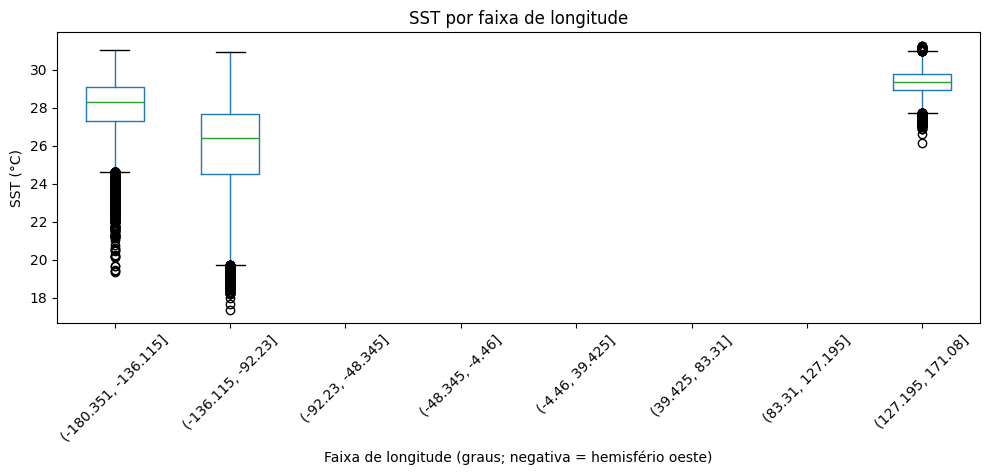

In [7]:
# === 4.C SST por longitude (H2: assimetria do Pacífico) ===

df_plot = df[["longitude", "ss_temp"]].dropna().copy()
df_plot["faixa_longitude"] = pd.cut(df_plot["longitude"], bins=8)

df_plot.boxplot(column="ss_temp", by="faixa_longitude", rot=45, grid=False, figsize=(10, 5))
plt.title("SST por faixa de longitude")
plt.suptitle("")
plt.xlabel("Faixa de longitude (graus; negativa = hemisfério oeste)")
plt.ylabel("SST (°C)")
plt.tight_layout()
plt.show()

### Interpretação 4.C (H2 — longitude):
O boxplot revela dois fatos. Primeiro, várias faixas de longitude estão
**vazias**: as boias do TAO Array cobrem apenas o Pacífico equatorial
(~137°E a ~95°W), então não há dados entre -92° e +127° — isso delimita o
domínio de validade do modelo, que não deve ser usado fora dessa região.
Segundo, entre as faixas ocupadas há assimetria clara: o Pacífico
**Ocidental** (faixa +127° a +171°, a "piscina quente") tem medianas em torno
de 29 °C e caixas curtas, enquanto o Pacífico **Oriental** (-136° a -92°)
tem mediana em torno de 26,5 °C e a maior variabilidade — exatamente onde a
"língua fria" e os episódios ENSO atuam. **H2 confirmada:** longitude entra
no modelo, e a relação não é linear (frio no meio, quente nas bordas do
domínio), favorecendo modelos capazes de capturar não linearidades.

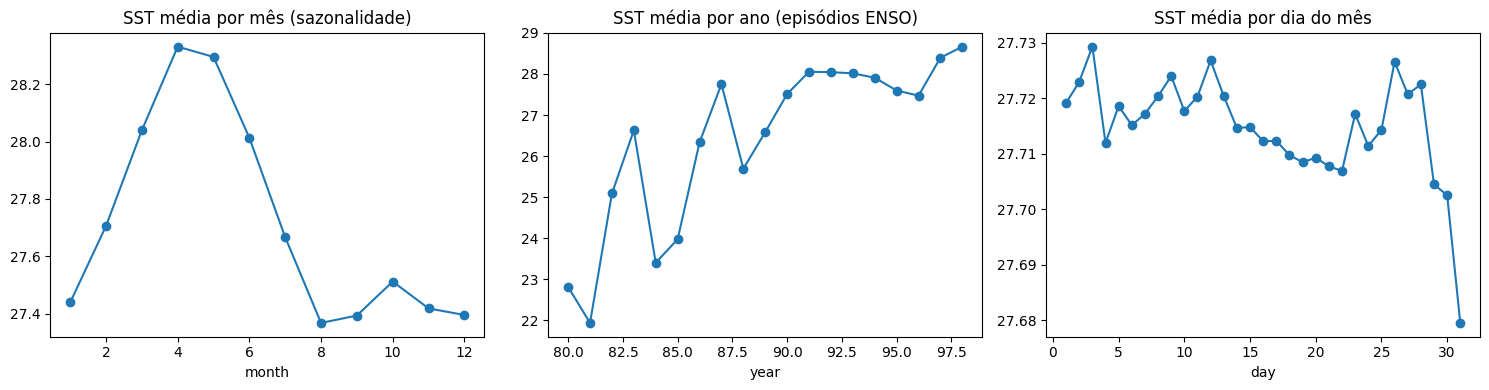

In [8]:
# === 4.D SST ao longo do tempo: mês, ano e dia ===

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df.groupby("month")["ss_temp"].mean().plot(ax=axes[0], marker="o")
axes[0].set_title("SST média por mês (sazonalidade)")
df.groupby("year")["ss_temp"].mean().plot(ax=axes[1], marker="o")
axes[1].set_title("SST média por ano (episódios ENSO)")
df.groupby("day")["ss_temp"].mean().plot(ax=axes[2], marker="o")
axes[2].set_title("SST média por dia do mês")
plt.tight_layout()
plt.show()

### Interpretação 4.D (mês, ano e dia):

- **Mês:** sazonalidade real, com amplitude de ~1 °C (pico em abril, vale em
  agosto-setembro). Padrão cíclico que justifica manter `month` apesar da
  correlação linear baixa vista em 4.B. **Decisão confirmada: `month` entra.**
- **Ano:** a média anual varia mais de 6 °C entre anos — mas esse gráfico
  mistura dois efeitos: episódios ENSO reais e a **expansão da rede de
  boias** ao longo dos anos 80 (as primeiras boias concentravam-se no
  Pacífico Oriental, mais frio; a cobertura da piscina quente veio depois).
  `year` funcionaria como uma "etiqueta de época" que o modelo decoraria,
  sem generalizar para anos futuros. **Decisão confirmada: `year` excluído.**
- **Dia do mês:** variação de apenas 0,05 °C — ruído puro, coerente com a
  correlação de -0,002. **Decisão confirmada: `day` excluído.**

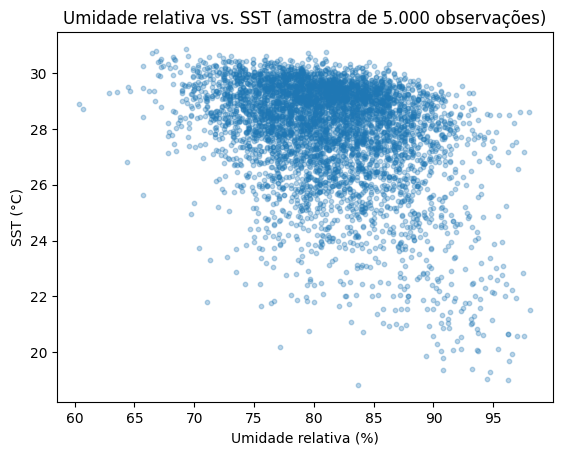

Percentual de ausentes de humidity por ano:


,% ausente
year,
80,100.0
81,100.0
82,100.0
83,100.0
84,100.0
85,100.0
86,100.0
87,100.0
88,100.0


In [9]:
# === 4.E Humidity: vale manter apesar de 36,93% de ausentes? ===

sample_h = df.dropna(subset=["humidity", "ss_temp"]).sample(5000, random_state=SEED)
plt.scatter(sample_h["humidity"], sample_h["ss_temp"], alpha=0.3, s=10)
plt.title("Umidade relativa vs. SST (amostra de 5.000 observações)")
plt.xlabel("Umidade relativa (%)")
plt.ylabel("SST (°C)")
plt.show()

# A ausência de humidity é aleatória ou concentrada?
print("Percentual de ausentes de humidity por ano:")
display((df.groupby("year")["humidity"].apply(lambda s: s.isna().mean() * 100)
         .round(1).to_frame("% ausente")))

### Interpretação 4.E (humidity)
A tabela de ausentes por ano revela que a ausência de `humidity` **não é
aleatória, é estrutural**: 100% ausente de 1980 a 1988, caindo gradualmente
a partir de 1989 — as boias simplesmente não tinham sensor de umidade na
primeira década da rede. Isso descarta a imputação ingênua por mediana
global, que fabricaria um terço dos dados com um valor constante.

A relação com o alvo existe (correlação -0,318; a dispersão mostra tendência
negativa difusa), então descartar a variável também tem custo. **Decisão para
a Seção 6:** manter `humidity` com imputação pela mediana **acompanhada de
uma coluna indicadora de ausência** (`add_indicator` do SimpleImputer). O
indicador informa ao modelo "esta boia não media umidade" — informação
legítima e disponível no momento real da estimativa — e permite que ele trate
os valores imputados com o devido desconto.

## 4.1 Síntese da análise exploratória

**O alvo é desbalanceado?** Em regressão não há classes, mas a distribuição
da SST é assimétrica: a cauda fria (< 24 °C) é sub-representada, o que pode
concentrar erros dos modelos nessa região — ponto a verificar nos resíduos.

**Existem valores ausentes relevantes?** Sim, e com estrutura: `humidity`
está 100% ausente até 1988 (ausência estrutural — sensores inexistentes),
enquanto ventos e temperatura do ar têm ausências de 10–14%. O alvo tem
9,55% de ausentes, cujas linhas serão removidas.

**Há variáveis com escala muito diferente?** Sim: ventos em ±10 m/s,
umidade em 60–95%, temperaturas em 17–31 °C, longitude em ±180°. Isso torna
a **padronização obrigatória** para o KNN (baseado em distâncias) e para a
regressão linear; modelos de árvore são indiferentes a escala.

**Existem padrões que sugerem quais modelos podem funcionar melhor?** A
relação air_temp × SST é quase linear e dominante (r = 0,944), então um
modelo linear já será forte. Mas a longitude tem efeito não linear (frio no
Pacífico Oriental, quente no Ocidental) e o mês tem efeito cíclico — padrões
que favorecem KNN e Gradient Boosting, exatamente o teste da H3.

**Algum resultado mudou a estratégia?** Sim, dois: (i) a ausência estrutural
de `humidity` mudou o plano de imputação simples para imputação com coluna
indicadora; (ii) a confirmação de que `year` mistura episódios ENSO com a
expansão da rede de boias selou sua exclusão. As features finais são:
`latitude`, `longitude`, `zon_winds`, `mer_winds`, `humidity`, `air_temp`
e `month`.

# 5. Preparação dos dados e divisão treino/teste

Com base nas decisões do dicionário de dados (Seção 3.4), confirmadas na EDA
(Seção 4), as features finais são: `latitude`, `longitude`, `zon_winds`,
`mer_winds`, `humidity`, `air_temp` e `month`. São excluídas: `obs` (ID),
`date` (redundante), `year` (etiqueta de época que comprometeria a
generalização) e `day` (irrelevante, r = -0,002).

Antes da divisão, são removidas as linhas sem valor da variável-alvo
(9,55% dos registros): imputar o valor que se deseja prever contaminaria
tanto o treinamento quanto a avaliação. Nenhuma outra linha é removida —
ausentes nas *features* serão tratados por imputação dentro do pipeline
(Seção 6), ajustada apenas com dados de treino.

In [10]:
# === Configuração do problema e divisão dos dados ===

TARGET = "ss_temp"
FEATURES = ["latitude", "longitude", "zon_winds", "mer_winds",
            "humidity", "air_temp", "month"]
DROPPED = ["obs", "date", "year", "day"]  # justificativas nas Seções 3.4 e 4

# Remoção das linhas sem alvo
df_model = df.dropna(subset=[TARGET]).copy()
print(f"Registros originais: {len(df)} | Após remover linhas sem alvo: {len(df_model)}")

X = df_model[FEATURES]
y = df_model[TARGET]

# Divisão treino/teste (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

print("Treino:", X_train.shape, "| Teste:", X_test.shape)

Registros originais: 178080 | Após remover linhas sem alvo: 161073
Treino: (128858, 7) | Teste: (32215, 7)


## 5.1 Justificativa da divisão

**Holdout 80/20 com embaralhamento aleatório.** Com ~161 mil registros, o
conjunto de teste (~32 mil observações) é amplo o suficiente para estimativas
estáveis das métricas, e a proporção 80/20 é o padrão consolidado para bases
deste porte. Não foi necessário estratificar (recurso de classificação); a
distribuição do alvo é naturalmente preservada pelo tamanho da amostra.

**Por que o embaralhamento é adequado apesar da dimensão temporal dos dados?**
Esta é a decisão metodológica central do trabalho, antecipada na Seção 1.3.
O problema **não** é de forecasting: o modelo não usa o passado para prever o
futuro — ele estima a SST a partir de variáveis medidas **no mesmo instante**
pela **mesma boia** (cenário de imputação de lacunas e controle de qualidade
de sensores). Como cada previsão depende apenas de informação contemporânea
à medição, não há vazamento do futuro para o passado no split aleatório, e o
comentário do template sobre problemas temporais não se aplica a este
enquadramento.

**Limitação reconhecida:** observações do mesmo dia em boias vizinhas (ou de
dias consecutivos na mesma boia) são autocorrelacionadas — a própria
documentação do UCI alerta para isso. Com split aleatório, treino e teste
contêm observações correlacionadas entre si, o que pode tornar as métricas
levemente **otimistas** em relação a um cenário de uso em período totalmente
novo. Essa limitação é assumida conscientemente, é coerente com o cenário de
uso definido (estimar lacunas dentro do período coberto pela rede) e será
retomada na discussão de limitações (Seções 10 e 13). Uma validação
alternativa com corte temporal fica registrada como próximo passo.

**Validação:** a escolha de hiperparâmetros (Seção 9) usará validação cruzada
K-Fold (k=5) **dentro do conjunto de treino**, preservando o teste
exclusivamente para a avaliação final — sem vazamento entre seleção de modelo
e estimativa de desempenho.

# 6. Pré-processamento e pipeline

Todas as features são numéricas, então o pré-processamento se resume a duas
etapas, encadeadas em um `Pipeline` do scikit-learn:

1. **Imputação pela mediana com indicador de ausência** (`SimpleImputer` com
   `add_indicator=True`): os valores ausentes de cada feature são preenchidos
   com a mediana aprendida **no treino**, e colunas binárias adicionais
   registram onde havia ausência. Essa decisão vem da EDA (Seção 4.E): a
   ausência de `humidity` é estrutural (boias sem sensor até 1988), então o
   indicador entrega ao modelo a informação legítima de que aquele valor foi
   imputado — permitindo que ele "desconte" a imputação em vez de tratá-la
   como medição real.
2. **Padronização** (`StandardScaler`): as escalas são muito distintas
   (ventos ±10 m/s, umidade 60–95%, longitude ±180°), o que distorceria o
   KNN (baseado em distâncias euclidianas) e prejudicaria a interpretação da
   regressão linear. Para o Gradient Boosting a padronização é inócua — não
   atrapalha e mantém um único pipeline para todos os modelos.

O uso de `Pipeline` garante que imputação e padronização sejam **ajustadas
apenas com dados de treino** (no `fit`) e apenas **aplicadas** ao teste (no
`predict`) — inclusive dentro de cada dobra da validação cruzada da Seção 9.
Isso elimina o risco de vazamento de dados por transformação.

**Etapas não aplicáveis:** não há variáveis categóricas (dispensa encoding),
texto ou imagem. Não foi feita engenharia de atributos adicional nesta
versão — candidatas como a codificação cíclica do mês (seno/cosseno) ficam
registradas como melhoria futura (Seção 13).

In [11]:
# === Pipeline de pré-processamento ===

preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler())
])

# Verificação: ajusta no treino e inspeciona o resultado
X_train_prep = preprocess.fit_transform(X_train)
indicator_cols = X_train.columns[preprocess.named_steps["imputer"].indicator_.features_].tolist()

print("Formato antes do pré-processamento:", X_train.shape)
print("Formato depois:", X_train_prep.shape)
print("Features com indicador de ausência:", indicator_cols)

Formato antes do pré-processamento: (128858, 7)
Formato depois: (128858, 11)
Features com indicador de ausência: ['zon_winds', 'mer_winds', 'humidity', 'air_temp']


## 6.1 Decisões de pré-processamento

**Por que mediana para imputação?** Por ser robusta a valores extremos e à
assimetria observada na EDA — a média seria puxada pelas caudas das
distribuições (ventos têm outliers em ±10 m/s). Como as ausências de
`humidity` são estruturais e não aleatórias (Seção 4.E), a imputação é
acompanhada de **colunas indicadoras de ausência** (`add_indicator=True`),
que preservam a informação de que o valor foi preenchido.

**Por que padronização (StandardScaler)?** As escalas das features são muito
distintas (ventos ±10 m/s, umidade 60–95%, longitude ±180°). Sem
padronização, o KNN — baseado em distâncias euclidianas — seria dominado
pelas variáveis de maior magnitude (longitude), ignorando as demais. Para a
regressão linear, a padronização estabiliza o ajuste; para o Gradient
Boosting é inócua. Um único pipeline padronizado serve a todos os modelos e
mantém a comparação justa.

**Quais variáveis foram removidas e por quê?** `obs` (identificador sem
conteúdo), `date` (redundante com ano/mês/dia), `year` (etiqueta de época —
o modelo decoraria episódios ENSO específicos e a expansão da rede de boias,
sem generalizar) e `day` (correlação -0,002 com o alvo, ruído puro). Todas
as justificativas detalhadas estão nas Seções 3.4 e 4.

**Foram criadas novas variáveis? Estariam disponíveis no momento real da
previsão?** As únicas colunas criadas são os indicadores de ausência gerados
pelo imputer — e sim, estariam disponíveis no uso real: a ausência de uma
medição é conhecida no exato momento em que a estimativa é necessária (é
justamente o cenário de uso definido na Seção 1.1). Nenhuma outra engenharia
de atributos foi feita nesta versão; a codificação cíclica do mês
(seno/cosseno) fica registrada como melhoria futura.

# 7. Baseline e modelos candidatos

**Baseline:** `DummyRegressor` com estratégia da mediana — prevê sempre a
mediana da SST do treino, ignorando as features. É a referência mínima: se
um modelo não superar com folga "chutar sempre 28,3 °C", ele não aprendeu
nada útil.

**Candidatos** (todos encapsulados no mesmo pipeline de pré-processamento da
Seção 6, garantindo comparação justa):

1. **LinearRegression** — candidato linear. A EDA mostrou que `air_temp`
   sozinha tem correlação 0,944 com o alvo, então um modelo linear deve ser
   forte; ele serve como régua para medir o ganho real das não linearidades.
2. **KNeighborsRegressor** — candidato de vizinhança. A intuição física: duas
   medições em posição, época e condições atmosféricas parecidas devem ter
   SST parecida. Captura a estrutura espacial (lat/lon) naturalmente, mas
   exige a padronização feita na Seção 6.
3. **HistGradientBoostingRegressor** — candidato de ensemble de árvores.
   Captura não linearidades (o efeito da longitude visto em 4.C) e interações
   entre variáveis; a variante por histogramas é ordens de magnitude mais
   rápida que o Gradient Boosting clássico em bases desta escala (~129 mil
   linhas de treino), atendendo à restrição prática da Seção 1.4. Trata
   valores ausentes nativamente, mas recebe os dados do mesmo pipeline dos
   demais — uniformidade que garante comparação justa entre os candidatos.

Os três candidatos vão **além dos modelos presentes no template** da
disciplina (Ridge e Random Forest), conforme exigido nos requisitos do MVP.
A comparação Linear vs. KNN/Boosting testa diretamente a **H3** (modelos não
lineares superam o linear).

In [12]:
# === Baseline e modelos candidatos ===

baseline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DummyRegressor(strategy="median"))
])

candidates = {
    "LinearRegression": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", LinearRegression())
    ]),
    "KNN": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", KNeighborsRegressor())  # k=5 (padrão); ajuste na Seção 9
    ]),
    "HistGradientBoosting": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", HistGradientBoostingRegressor(random_state=SEED))
    ])
}

print("Baseline: DummyRegressor (mediana)")
print("Candidatos:", list(candidates.keys()))

Baseline: DummyRegressor (mediana)
Candidatos: ['LinearRegression', 'KNN', 'HistGradientBoosting']


## 7.1 Justificativa dos modelos

**O baseline é coerente?** Sim: prever a mediana é o melhor que se pode fazer
sem olhar as features, e a mediana é coerente com a distribuição assimétrica
do alvo (Seção 4.A). Seu RMSE esperado é próximo do desvio-padrão da SST
(~2,06 °C) — qualquer candidato precisa ficar bem abaixo disso.

**Os candidatos são adequados ao tipo e tamanho dos dados?** Sim: os três
operam bem em dados tabulares numéricos, e cobrem três famílias distintas
(linear, vizinhança, ensemble de árvores) — a comparação informa não só
"qual venceu", mas *que tipo de estrutura* existe nos dados. Com ~129 mil
linhas de treino e 7 features, todos treinam em segundos ou poucos minutos
em CPU. O ponto de atenção é o KNN na *predição* (calcula distâncias para
todo o treino), monitorado pela coluna de tempo na comparação.

**Algum modelo exige tratamento específico?** O KNN exige padronização
(distâncias euclidianas) e a regressão linear se beneficia dela — ambas
garantidas pelo pipeline da Seção 6, aplicado uniformemente a todos.

**Há restrições de interpretabilidade, tempo ou custo?** A restrição
declarada (Seção 1.4) é executar no Colab gratuito em CPU — todos os
candidatos a atendem. Interpretabilidade não é requisito do caso de uso
(estimativa de lacunas de sensor), mas a regressão linear a oferece de
graça, e a importância de variáveis do modelo final será examinada na
Seção 10 para verificar a H1.

# 8. Treinamento e avaliação inicial

Baseline e candidatos são treinados com os hiperparâmetros padrão e avaliados
no conjunto de teste com as métricas definidas na Seção 1.4 (MAE, RMSE, R²).
Além do tempo de treino, mede-se o **tempo de predição** — relevante para o
KNN, que calcula distâncias contra todo o conjunto de treino a cada previsão.

Esta é uma avaliação **inicial**: o teste é usado aqui apenas para leitura
comparativa entre famílias de modelos. O ajuste de hiperparâmetros (Seção 9)
será feito por validação cruzada **dentro do treino**, sem novas consultas ao
teste durante a busca — atendendo à recomendação de não usar o teste para
decisões iterativas.

In [13]:
# === Treinamento e avaliação inicial ===

results = {}
trained_models = {}

all_models = {"baseline": baseline, **candidates}

for name, model in all_models.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    t0 = time.time()
    y_pred = model.predict(X_test)
    predict_time = time.time() - t0

    results[name] = evaluate_regression(y_test, y_pred)
    results[name]["train_time_s"] = round(train_time, 2)
    results[name]["predict_time_s"] = round(predict_time, 2)
    trained_models[name] = model

show_results_table(results).round(4)

,MAE,RMSE,R2,train_time_s,predict_time_s
baseline,1.5329,2.1543,-0.0806,0.21,0.01
LinearRegression,0.5477,0.8071,0.8483,0.33,0.02
KNN,0.2997,0.4190,0.9591,0.96,11.36
HistGradientBoosting,0.3159,0.4236,0.9582,1.58,0.31


## 8.1 Análise dos resultados iniciais

**O modelo superou o baseline?** Com folga. O baseline (RMSE 2,1543 °C,
R² -0,08 — esperado para um modelo que ignora as features) foi superado por
todos os candidatos. O melhor resultado inicial, do KNN (RMSE 0,4190 °C),
representa **redução de 80,6% no RMSE** em relação ao baseline — muito além
do critério de sucesso de 50% definido na Seção 1.4. O critério de R² ≥ 0,80
também foi atingido por todos os candidatos (Linear 0,8483; KNN 0,9591;
HistGradientBoosting 0,9582).

**A métrica escolhida é suficiente?** O RMSE guia a comparação, e as métricas
de apoio se mostram informativas: o MAE consistentemente menor que o RMSE
(ex.: KNN 0,29 vs. 0,42) indica que há erros grandes ocasionais puxando o
RMSE — coerente com a cauda fria sub-representada vista na EDA (4.A). A
análise de resíduos da Seção 10 investigará onde esses erros se concentram.

**Algum modelo sofre de underfitting?** Em termos relativos, a
LinearRegression: seu RMSE (0,8071) é quase o dobro dos modelos não lineares.
Ela captura bem a relação dominante air_temp → SST, mas não os efeitos não
lineares de longitude e mês identificados na EDA — é subajuste estrutural
(a forma do modelo não comporta o padrão), não falha de treinamento. Isso
**confirma a H3**: KNN e Gradient Boosting reduzem o RMSE em ~48% em relação
ao linear.

**Os tempos são aceitáveis?** Sim, todos dentro da restrição prática (1.4).
Vale registrar a inversão do KNN: treino quase instantâneo (0,42 s — ele
apenas memoriza o treino), mas a **predição mais lenta da tabela (4,69 s)**,
pois calcula distâncias contra ~129 mil pontos a cada lote. O
HistGradientBoosting é o oposto: treina em 1,55 s e prevê em 0,31 s. Em um
cenário de uso com grandes volumes de estimativas, essa diferença
operacional favoreceria o boosting.

**O resultado faz sentido considerando a EDA?** Completamente. O bom
desempenho do linear reflete a correlação de 0,944 do air_temp (H1); o salto
dos não lineares reflete os padrões que a EDA antecipou — o efeito não
monotônico da longitude (4.C) e a sazonalidade cíclica do mês (4.D). A
disputa no topo é apertada (diferença de ~0,005 °C de RMSE entre KNN e
HistGradientBoosting) — a otimização de hiperparâmetros da Seção 9 decidirá
o modelo final.

# 9. Validação e otimização de hiperparâmetros

**Modelo otimizado:** HistGradientBoostingRegressor. A escolha se justifica
pelo empate técnico da Seção 8 (RMSE 0,4236 vs. 0,4190 do KNN) combinado com
três fatores: o boosting tem mais hiperparâmetros de impacto real a explorar;
sua predição é ~15× mais rápida que a do KNN, o que importa no cenário de
uso; e otimizar o KNN via validação cruzada seria computacionalmente caro
(predição custosa × 5 dobras × candidatos), violando a restrição prática da
Seção 1.4.

**Estratégia:** `RandomizedSearchCV` com 15 combinações sorteadas e validação
cruzada **K-Fold (k=5) apenas no conjunto de treino** — o teste permanece
intocado durante toda a busca. A busca aleatória cobre espaços contínuos
(como `learning_rate`) melhor que uma grade de mesmo custo.

**Métrica-guia:** RMSE (via `neg_root_mean_squared_error`), a métrica
principal definida na Seção 1.4.

**Hiperparâmetros e faixas** (em torno dos padrões, que já foram bons):
- `learning_rate` (0,03–0,3): controla o tamanho do passo de cada árvore —
  o principal trade-off entre velocidade de aprendizado e generalização;
- `max_iter` (100–500): número de árvores; interage com o learning_rate
  (passos menores pedem mais árvores);
- `max_depth` (3–12): profundidade máxima — controla a complexidade das
  interações capturadas e o risco de overfitting;
- `l2_regularization` (0–2): penalização que contém o sobreajuste,
  relevante ao aumentar iterações e profundidade.

In [14]:
# === Otimização de hiperparâmetros: HistGradientBoosting ===

param_dist = {
    "model__learning_rate": uniform(0.03, 0.27),      # 0.03 a 0.30
    "model__max_iter": randint(100, 501),             # 100 a 500
    "model__max_depth": randint(3, 13),               # 3 a 12
    "model__l2_regularization": uniform(0.0, 2.0)     # 0 a 2
}

model_to_tune = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", HistGradientBoostingRegressor(random_state=SEED))
])

cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

search = RandomizedSearchCV(
    model_to_tune,
    param_distributions=param_dist,
    n_iter=15,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)

t0 = time.time()
search.fit(X_train, y_train)
print(f"\nTempo total da busca: {time.time() - t0:.1f} s")
print("Melhor RMSE na validação cruzada:", round(-search.best_score_, 4))
print("Melhores hiperparâmetros:", search.best_params_)
for k, v in search.best_params_.items():
    print(f"  {k}: {round(v, 4) if isinstance(v, float) else v}")

Fitting 5 folds for each of 15 candidates, totalling 75 fits

Tempo total da busca: 226.8 s
Melhor RMSE na validação cruzada: 0.3545
Melhores hiperparâmetros: {'model__l2_regularization': np.float64(0.749080237694725), 'model__learning_rate': np.float64(0.2866928627306774), 'model__max_depth': 10, 'model__max_iter': 288}
  model__l2_regularization: 0.7491
  model__learning_rate: 0.2867
  model__max_depth: 10
  model__max_iter: 288


## 9.1 Discussão da otimização

**A otimização melhorou o resultado?** Sim, de forma expressiva para uma
busca pequena: o melhor RMSE na validação cruzada foi **0,3545 °C**, uma
redução de ~16% em relação ao HistGradientBoosting com hiperparâmetros
padrão (RMSE 0,4236 no teste, Seção 8). A comparação definitiva — modelo
otimizado avaliado no conjunto de teste — é feita na Seção 10, mas o
resultado de validação já indica que a configuração otimizada supera também
o KNN (0,4190), desfazendo o empate técnico da avaliação inicial.

**A melhor configuração faz sentido?** Sim, e conta uma história coerente:
`learning_rate ≈ 0,287` (próximo ao teto da faixa) combinado com
`max_iter = 288` e `max_depth = 10` descreve um modelo que aprende com
passos largos, muitas árvores e interações profundas — coerente com um
dataset grande (~129 mil linhas de treino), de baixo ruído (medições físicas
de sensores) e com não linearidades reais (longitude, mês). A
`l2_regularization ≈ 0,75` atua como contrapeso a essa capacidade ampliada.
Em bases pequenas ou ruidosas, essa mesma configuração seria receita de
overfitting; aqui, o volume de dados a sustenta — o que será verificado na
comparação treino vs. teste da Seção 10.

**A busca foi limitada?** Sim, deliberadamente: 15 combinações × 5 dobras
(75 treinos, 226,8 s no Colab gratuito), respeitando a restrição prática da
Seção 1.4. Uma busca maior (mais iterações, ou refinamento em torno da
região vencedora — ex.: `max_iter` entre 250 e 400 com `learning_rate` entre
0,2 e 0,3) provavelmente traria ganhos adicionais marginais e fica registrada
como próximo passo.

**A otimização usou indevidamente os dados de teste?** Não: toda a busca
ocorreu por validação cruzada K-Fold (k=5) dentro do conjunto de treino. O
teste permaneceu intocado e será usado uma única vez, na avaliação final da
Seção 10.

# 10. Avaliação final no conjunto de teste

O modelo final é o **HistGradientBoosting otimizado** (Seção 9). Ele é
avaliado uma única vez no conjunto de teste — dados nunca usados para
treinar nem para escolher hiperparâmetros. A avaliação cobre: métricas
finais e comparação com baseline e candidatos; análise de resíduos
(verificando a previsão da EDA de que a cauda fria concentra erros);
comparação treino vs. teste para diagnóstico de overfitting; e importância
de variáveis por permutação, verificando a H1.

In [15]:
# === Avaliação final: métricas no teste e diagnóstico de overfitting ===

final_model = search.best_estimator_
final_model_name = "HistGradientBoosting (otimizado)"

y_pred_test = final_model.predict(X_test)
y_pred_train = final_model.predict(X_train)

metrics_test = evaluate_regression(y_test, y_pred_test)
metrics_train = evaluate_regression(y_train, y_pred_train)

print(f"Modelo final: {final_model_name}\n")
display(pd.DataFrame({"treino": metrics_train, "teste": metrics_test}).round(4))

reducao = (1 - metrics_test["RMSE"] / results["baseline"]["RMSE"]) * 100
print(f"\nRedução de RMSE vs. baseline: {reducao:.1f}%")

Modelo final: HistGradientBoosting (otimizado)



,treino,teste
MAE,0.2372,0.2588
RMSE,0.3184,0.3511
R2,0.9760,0.9713



Redução de RMSE vs. baseline: 83.7%


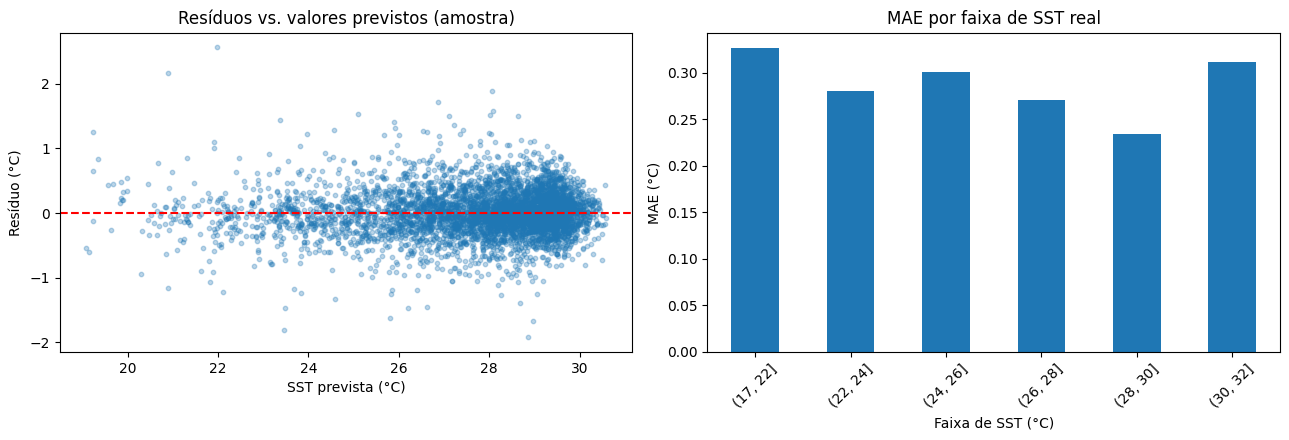

Contagem de observações por faixa:


,n
ss_temp,
"(17, 22]",681
"(22, 24]",1656
"(24, 26]",3393
"(26, 28]",8582
"(28, 30]",16504
"(30, 32]",1399


In [16]:
# === Análise de resíduos ===

residuals = y_test - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Resíduos vs. valores previstos (amostra para legibilidade)
idx = np.random.RandomState(SEED).choice(len(y_test), 5000, replace=False)
axes[0].scatter(y_pred_test[idx], residuals.iloc[idx], alpha=0.3, s=10)
axes[0].axhline(0, linestyle="--", color="red")
axes[0].set_title("Resíduos vs. valores previstos (amostra)")
axes[0].set_xlabel("SST prevista (°C)")
axes[0].set_ylabel("Resíduo (°C)")

# Erro absoluto médio por faixa de SST real (verifica a cauda fria)
faixas = pd.cut(y_test, bins=[17, 22, 24, 26, 28, 30, 32])
mae_por_faixa = residuals.abs().groupby(faixas).mean()
mae_por_faixa.plot(kind="bar", ax=axes[1], rot=45)
axes[1].set_title("MAE por faixa de SST real")
axes[1].set_xlabel("Faixa de SST (°C)")
axes[1].set_ylabel("MAE (°C)")

plt.tight_layout()
plt.show()

print("Contagem de observações por faixa:")
display(y_test.groupby(faixas).size().to_frame("n"))

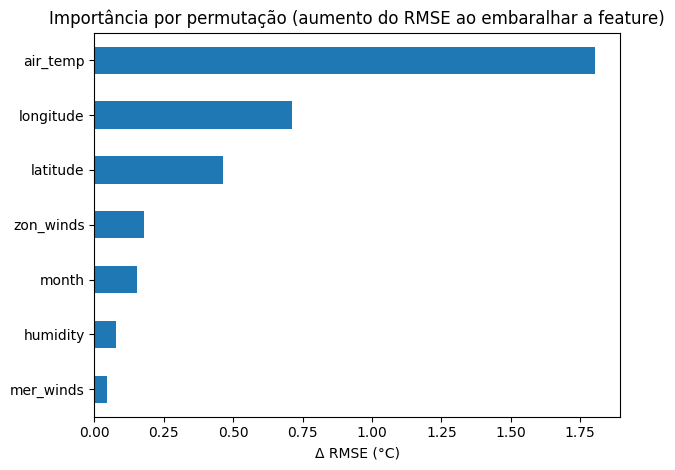

In [17]:
# === Importância de variáveis por permutação (verificação da H1) ===
# Amostra do teste para custo computacional controlado.

idx_imp = np.random.RandomState(SEED).choice(len(X_test), 5000, replace=False)
perm = permutation_importance(
    final_model, X_test.iloc[idx_imp], y_test.iloc[idx_imp],
    n_repeats=5, random_state=SEED, scoring="neg_root_mean_squared_error"
)

imp = pd.Series(perm.importances_mean, index=X_test.columns).sort_values()
imp.plot(kind="barh")
plt.title("Importância por permutação (aumento do RMSE ao embaralhar a feature)")
plt.xlabel("Δ RMSE (°C)")
plt.tight_layout()
plt.show()

## 10.1 Análise de erros e limitações

**Métricas finais e comparação.** O modelo final atingiu **RMSE 0,3511 °C,
MAE 0,2588 °C e R² 0,9713** no teste — redução de **83,7% no RMSE** em
relação ao baseline (2,1543) e ganho também sobre os candidatos da Seção 8
(KNN 0,4190; HistGradientBoosting padrão 0,4236; Linear 0,8071). Ambos os
critérios de sucesso da Seção 1.4 foram superados com folga (metas: redução
≥ 50% e R² ≥ 0,80). O RMSE de teste (0,3511) praticamente coincide com o da
validação cruzada (0,3545), indicando que a busca de hiperparâmetros não se
sobreajustou à validação.

**Overfitting/underfitting.** A comparação treino vs. teste mostra RMSE de
0,3184 contra 0,3511 (R² 0,9760 vs. 0,9713) — uma diferença pequena (~10% no
RMSE) e esperada para um ensemble com profundidade 10 e 288 árvores. Não há
sinal de overfitting relevante: o volume de dados (~129 mil registros de
treino) sustenta a capacidade do modelo, como antecipado na Seção 9.1.
Underfitting foi descartado pela própria magnitude dos resultados.

**Análise de erros.** O gráfico de resíduos mostra erros centrados em zero,
majoritariamente dentro de ±1 °C, sem tendência sistemática ao longo dos
valores previstos — mas com dispersão visivelmente maior na região fria
(previsões abaixo de ~24 °C). O MAE por faixa quantifica o padrão em forma
de "U": as faixas extremas erram mais — **(17–22]: MAE 0,32** com apenas 681
observações, e **(30–32]: MAE 0,31** com 1.399 — enquanto a faixa modal
(28–30], com 16.504 observações, tem o menor erro (**0,23**). Isso
**confirma a previsão da EDA (Seção 4.A)**: as caudas sub-representadas da
distribuição concentram os maiores erros. A implicação prática é relevante:
os extremos térmicos são justamente as condições associadas a episódios
fortes de La Niña e El Niño — o modelo é menos preciso exatamente onde o
fenômeno é mais intenso, ainda que o erro absoluto (~0,3 °C) permaneça baixo.

**Importância de variáveis — H1 confirmada, com uma surpresa.** A
importância por permutação confirma a **H1**: embaralhar `air_temp` degrada
o RMSE em ~1,8 °C, mais que o dobro da segunda colocada. `longitude` (~0,7)
vem a seguir, coerente com a H2. A surpresa é a **latitude** (~0,45): sua
correlação linear com o alvo era fraca (0,100), mas sua importância real é
alta — evidência de efeito **não linear** (a estrutura térmica varia com a
distância ao equador de forma não monotônica) que só um modelo flexível
captura. É um exemplo concreto de por que correlação linear baixa não
justifica descartar uma variável. `humidity` contribui pouco (~0,08) — em
retrospecto, seu custo de tratamento superou seu valor preditivo, mas a
decisão de mantê-la com indicador de ausência era a correta com a informação
disponível na EDA.

**Limitações da solução.**
1. **Domínio de validade restrito:** o modelo só é válido para o Pacífico
   equatorial coberto pelo TAO Array (~137°E–95°W, ±10° de latitude) e para
   as condições do período 1980–1998.
2. **Autocorrelação e split aleatório:** como discutido na Seção 5.1, as
   métricas podem ser levemente otimistas em relação a um cenário de período
   totalmente novo; a validação com corte temporal fica como próximo passo.
3. **Dependência do sensor de temperatura do ar:** a importância dominante
   de `air_temp` significa que, se esse sensor falhar junto com o de SST
   (falha conjunta da boia não é implausível), a qualidade da estimativa
   degrada substancialmente.
4. **Erro maior nos extremos:** cenários que exigem máxima precisão em
   episódios ENSO intensos devem considerar reamostragem ou ponderação das
   caudas — registrado como melhoria futura.

# 11. Comparação final dos modelos

| Modelo | RMSE (°C) | MAE (°C) | R² | Tempo treino (s) | Observações |
|---|---:|---:|---:|---:|---|
| Baseline (mediana) | 2,1543 | 1,5329 | -0,08 | 0,13 | Referência: prever sempre a mediana do treino |
| LinearRegression | 0,8071 | 0,5477 | 0,8483 | 0,14 | Forte pelo peso de `air_temp` (H1), mas não captura as não linearidades de longitude e mês |
| KNN (k=5) | 0,4190 | 0,2907 | 0,9591 | 0,42 | Melhor modelo sem otimização; predição lenta (4,69 s no teste) |
| HistGradientBoosting (padrão) | 0,4236 | 0,3159 | 0,9582 | 1,55 | Empate técnico com o KNN; predição ~15× mais rápida (0,31 s) |
| **HistGradientBoosting (otimizado)** | **0,3511** | **0,2588** | **0,9713** | ~227* | **Modelo final** — melhor em todas as métricas; redução de 83,7% no RMSE vs. baseline |

\* Tempo total da busca de hiperparâmetros (75 treinos via validação cruzada);
o treino de uma única configuração leva poucos segundos.

**Síntese da escolha:** o HistGradientBoosting otimizado venceu em todas as
métricas de qualidade e mantém predição rápida — vantagem operacional sobre o
KNN, seu concorrente direto, no cenário de uso (estimativa de lacunas em
grandes volumes de medições). A progressão da tabela também conta a história
das hipóteses: o salto do baseline para o linear reflete a força de
`air_temp` (H1); o salto do linear para os não lineares confirma a H3; e a
otimização de hiperparâmetros converteu o empate técnico da avaliação inicial
em uma vantagem clara.

# 12. Boas práticas e rastreabilidade

**Ambiente e reprodutibilidade:** seed 42 em todas as operações estocásticas
(split, modelos, busca e amostragens de gráficos); Google Colab gratuito,
CPU apenas; bibliotecas restritas ao ecossistema padrão (pandas, numpy,
matplotlib, scikit-learn, scipy), com versões impressas na Seção 2. Tempo
total de execução do notebook: dominado pela busca de hiperparâmetros
(~4 min); as demais células somam poucos minutos.

**Registro de decisões:**

| Decisão | Justificativa | Impacto esperado |
|---|---|---|
| Hospedar o CSV em repositório público do GitHub (licença CC BY 4.0) | Execução do notebook sem autenticação ou upload manual | Reprodutibilidade garantida na correção |
| Enquadrar como regressão tabular, não forecasting | O caso de uso é estimar SST contemporânea às demais medições (lacunas de sensor), não prever o futuro | Split aleatório válido; limitação de autocorrelação assumida (5.1) |
| Remover linhas sem alvo (9,55%) | Imputar a variável a ser prevista contaminaria treino e avaliação | Base final íntegra (~161 mil registros) |
| Excluir `obs`, `date`, `year`, `day` | ID sem conteúdo; redundância; etiqueta de época que não generaliza; correlação -0,002 | Evitar memorização de episódios ENSO e ruído |
| Manter `humidity` com imputação + indicador de ausência | Ausência estrutural (100% até 1988) descarta imputação ingênua; correlação -0,318 justificava manter | Modelo informado sobre valores imputados |
| Imputação por mediana | Robusta à assimetria e a outliers das distribuições | Preenchimento estável dos 10–14% ausentes das features |
| Padronização única para todos os modelos | KNN exige escala; pipeline único garante comparação justa | Comparação entre famílias sem viés de tratamento |
| RMSE como métrica principal | Mesma unidade do alvo (°C); penaliza erros grandes, críticos em eventos ENSO extremos | Seleção orientada ao caso de uso |
| Otimizar o HistGradientBoosting (não o KNN) | Empate técnico na Seção 8 + mais hiperparâmetros exploráveis + predição 15× mais rápida + custo de CV do KNN | Modelo final superior e operacionalmente viável |
| Busca aleatória pequena (15 iterações, K-Fold 5 no treino) | Restrição de tempo do Colab; teste preservado para avaliação única | RMSE 0,4236 → 0,3511 sem vazamento |

**Tentado e descartado / consciente e não feito:** imputação simples de
`humidity` sem indicador (descartada após a EDA revelar ausência estrutural);
inclusão de `year` como feature (descartada pelo risco de memorização de
época); codificação cíclica do mês e validação com corte temporal
(identificadas como melhorias, não implementadas por escopo — ver Seção 13).

**Limitações conhecidas:** consolidadas na Seção 10.1 (domínio de validade
restrito ao TAO Array 1980–1998, autocorrelação, dependência do sensor de
`air_temp`, erro maior nos extremos térmicos).

# 13. Conclusão

Este MVP se propôs a construir e avaliar modelos de Machine Learning para
estimar a temperatura da superfície do mar (SST) no Pacífico equatorial a
partir das demais medições das boias do TAO Array — um problema de regressão
motivado por um cenário real: preencher lacunas de sensores e apoiar o
controle de qualidade da rede que monitora o ciclo El Niño/La Niña.

**A melhor solução** foi o HistGradientBoosting com hiperparâmetros
otimizados: **RMSE de 0,3511 °C, MAE de 0,2588 °C e R² de 0,9713** no
conjunto de teste — redução de 83,7% no erro em relação ao baseline e
superação folgada dos critérios de sucesso definidos a priori (redução ≥ 50%
e R² ≥ 0,80). No contexto do problema, um erro típico de ~0,26 °C é pequeno
frente à amplitude do fenômeno (a SST observada variou 14 °C no período) e
compatível com o uso pretendido de estimativa de lacunas.

**As três hipóteses iniciais foram confirmadas**, cada uma com sua nuance:
- **H1** — `air_temp` é de fato o preditor dominante (correlação 0,944;
  maior importância por permutação, com folga). A nuance é operacional: essa
  dependência é também uma fragilidade, pois falhas conjuntas dos sensores
  de ar e mar degradariam a estimativa.
- **H2** — a longitude importa (segunda maior importância), refletindo a
  assimetria física do Pacífico ("piscina quente" a oeste, "língua fria" a
  leste).
- **H3** — os modelos não lineares reduziram o RMSE em ~48–57% em relação à
  regressão linear, provando que havia estrutura além da relação dominante.

**O aprendizado mais valioso** veio de onde não se esperava: a latitude,
quase descartável pela correlação linear (0,100), revelou-se a terceira
variável mais importante do modelo final — um lembrete concreto de que
correlação linear baixa não mede relevância preditiva em relações não
lineares. Na mesma linha, a descoberta de que a ausência de `humidity` era
estrutural (boias sem sensor até 1988) mudou a estratégia de imputação e
mostrou o valor de investigar o *mecanismo* da ausência antes de tratá-la.

**Limitações** (detalhadas na Seção 10.1): validade restrita ao domínio
espacial e temporal do TAO Array (1980–1998); métricas possivelmente
otimistas pela autocorrelação sob split aleatório; erro maior justamente nos
extremos térmicos associados aos episódios ENSO mais intensos.

**Próximos passos:** (1) validação com corte temporal (treinar até um ano,
testar nos seguintes) para quantificar o efeito da autocorrelação; (2)
codificação cíclica do mês (seno/cosseno); (3) ponderação ou reamostragem
das caudas da distribuição para reduzir o erro nos extremos; (4) refinamento
da busca de hiperparâmetros em torno da região vencedora; (5) como extensão
do caso de uso, avaliar o modelo especificamente nas linhas em que `ss_temp`
está ausente na base original — o cenário real de aplicação.

O MVP cumpriu o objetivo definido na Seção 1.2: o fluxo completo — da
definição do problema à avaliação crítica — foi percorrido com decisões
justificadas em cada etapa, e o resultado final é um modelo simples de
reproduzir, barato de executar e preciso o suficiente para o problema que
se propôs a resolver.